In [1]:
#importing packages
import os
import cv2
import numpy as np
import pandas as pd

from tensorflow import keras
from keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from keras.models import Sequential
from matplotlib import pyplot
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score
import seaborn as sns
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import Model
from keras.models import model_from_json
from keras.preprocessing import image
from tensorflow.keras import optimizers
from tensorflow.keras.applications import Xception
from keras import applications

2026-01-09 13:37:06.315942: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-09 13:37:06.352383: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 13:37:07.377417: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/Course/Project_Sign_Language/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
def load_subdata(data, SIZE):
    X1 = []
    y1 = []
    size = SIZE
    lbl = 0
    dic = {}
    
    # Sort folder names to ensure consistent ordering
    for folder_name in sorted(os.listdir(data)):
        Label = lbl
        dic[folder_name] = Label  
        count_img = 0
        
        # Loop through each image in the current class folder
        for filename in os.listdir(data + '/' + folder_name):
            try:
                image = tf.keras.preprocessing.image.load_img(data + '/' + folder_name + '/' + filename, color_mode='rgb', target_size=(size, size))
                arr = keras.preprocessing.image.img_to_array(image) / 255.0
                X1.append(arr)
                y1.append(Label)
            except Exception as e:
                print(f"Error loading image {filename}: {e}")
                
        lbl += 1
    
    X1 = np.asarray(X1).reshape(len(X1), size, size, 3).astype(np.float32)
    y1 = np.asarray(y1).astype(np.uint8)
    
    return X1, y1, dic

In [3]:
X, y, label_dic = load_subdata('../database', 224)

In [4]:
label_dic

{'0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9}

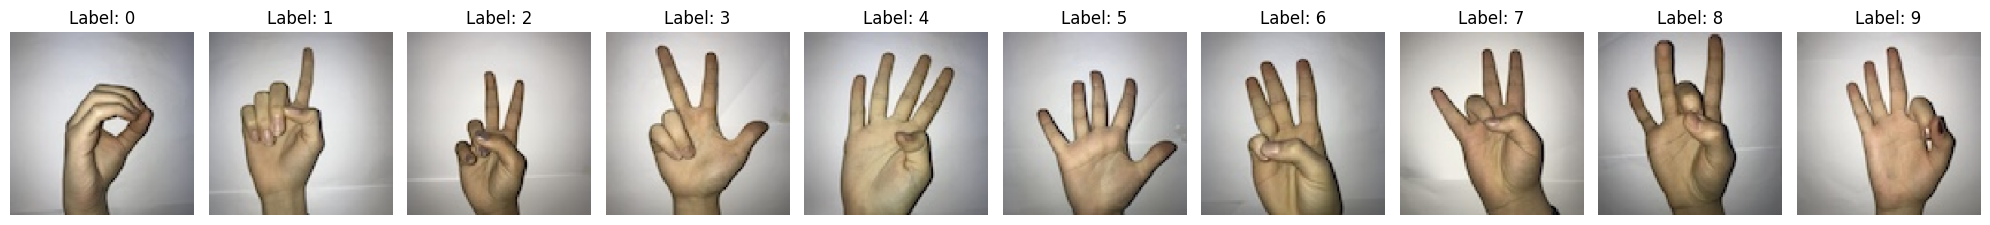

In [5]:
# Display one image from each label (0 to 9)
def display_images_by_label(X, y, label_dic, num_classes=10):
    plt.figure(figsize=(20, 4))
    
    for label in range(num_classes):
        # Find the first image with this label
        idx = np.where(y == label)[0][0]
        
        plt.subplot(1, num_classes, label + 1)
        plt.imshow(X[idx])
        plt.title(f"Label: {list(label_dic.keys())[label]}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Display one image for each label (0-9)
display_images_by_label(X, y, label_dic, num_classes=10)

# EDA

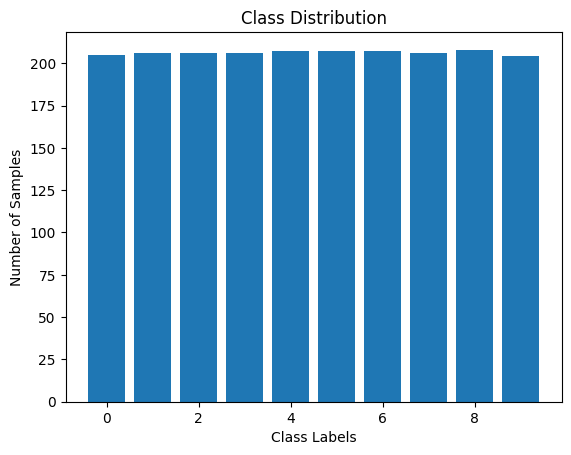

In [6]:
# Check the Class Distribution

# Plot class distribution
def plot_class_distribution(y):
    unique, counts = np.unique(y, return_counts=True)
    plt.bar(unique, counts)
    plt.xlabel('Class Labels')
    plt.ylabel('Number of Samples')
    plt.title('Class Distribution')
    plt.show()

plot_class_distribution(y)  # Visualize class distribution


In [7]:
# check shape of the image

print("X shape:", X.shape)
print("Image dimensions: Height={}, Width={}, Channels={}".format(X.shape[1], X.shape[2], X.shape[3]))




X shape: (2062, 224, 224, 3)
Image dimensions: Height=224, Width=224, Channels=3


In [8]:
from sklearn.utils import shuffle
X_new , y_new = shuffle(X, y, random_state=32)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_Test, y_train, y_Test = train_test_split(X_new , y_new, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_Test , y_Test, test_size=0.5, random_state=42)

In [10]:
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Training set size: 1443
Validation set size: 309
Test set size: 310


1. Data Augmentation:

Data augmentation is a technique used to artificially increase the size of a dataset by applying random transformations to the training images, such as rotations, flipping, zooming, etc. This helps to prevent overfitting and improve the model's generalization.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator




# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=40,        # Random rotation between -40 and 40 degrees
    width_shift_range=0.2,    # Horizontal shift
    height_shift_range=0.2,   # Vertical shift
    shear_range=0.2,          # Shear transformation
    zoom_range=0.2,           # Zoom in/out
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest'       # Fill pixels that get empty due to transformation
)


# Example: Apply augmentation to the first image in the dataset
sample_image = X_train[0].reshape((1,) + X_train[0].shape)  # Reshape image to 4D (batch, height, width, channels)
i = 0
for batch in datagen.flow(sample_image, batch_size=1, save_to_dir='../../augemented_data', save_prefix='aug', save_format='jpeg'):
    i += 1
    if i > 5:  # Save 5 augmented images for visualization
        break

In [12]:
y_trainHot = np.uint8(to_categorical(y_train, num_classes = 10))
y_testHot = np.uint8(to_categorical(y_test, num_classes = 10))
y_valHot = np.uint8(to_categorical(y_val, num_classes = 10))


In [13]:
print("One hot encoded labels")
print(y_trainHot.shape)
print(y_testHot.shape)
print(y_valHot.shape)

One hot encoded labels
(1443, 10)
(310, 10)
(309, 10)


In [14]:
print("Training Images Shape (x train shape) :", X_train.shape)
print("Label of training images (y train shape) :",y_train.shape)

print("Validation Images Shape (x val shape) :",X_val.shape)
print("Label of Validation images (y val shape) :",y_val.shape)

print("Test Images Shape (x val shape) :",X_test.shape)
print("Label of Test images (y val shape) :",y_test.shape)

Training Images Shape (x train shape) : (1443, 224, 224, 3)
Label of training images (y train shape) : (1443,)
Validation Images Shape (x val shape) : (309, 224, 224, 3)
Label of Validation images (y val shape) : (309,)
Test Images Shape (x val shape) : (310, 224, 224, 3)
Label of Test images (y val shape) : (310,)


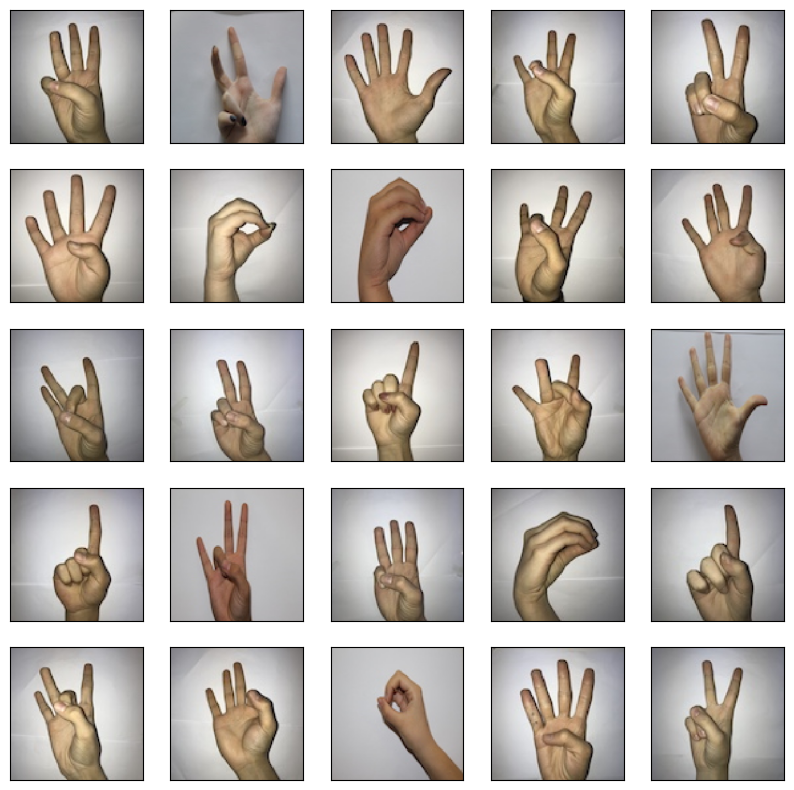

In [15]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    
plt.show()

# Model AlexNet Original

In [16]:
from tensorflow.keras import layers, models
lr = 0.0001

# Define the AlexNet architecture
def build_alexnet_original(input_shape, num_classes):
    model = models.Sequential()

    # Conv Layer 1
    model.add(Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(3, 3), strides=2))
    
    # Conv Layer 2
    model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3, 3), strides=2))

    # Conv Layer 3
    model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
    
    # Conv Layer 4
    model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
    
    # Conv Layer 5
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3, 3), strides=2))
    
    # Flatten the output for the fully connected layers
    model.add(Flatten())
    
    # Fully Connected Layer 1
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))  # Dropout to prevent overfitting
    # Fully Connected Layer 2
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))  # Dropout to prevent overfitting

    # Fully Connected Layer 3 (Output layer)
    model.add(Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',  # Using sparse categorical cross-entropy for integer labels
        metrics=['accuracy']
    )

    return model

In [17]:
# Build the AlexNet model
input_shape = (224, 224, 3)  # Images are resized to 128x128x3
num_classes = len(label_dic)  # Number of classes in the dataset

original_model = build_alexnet_original(input_shape, num_classes)

# Print the model summary
original_model.summary()


/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/Course/Project_Sign_Language/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1767940632.162215    9775 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1767940632.169849    9775 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GP

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,787,978 (178.48 MB)

 Trainable params: 46,787,978 (178.48 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the model
history = original_model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_data=(X_val, y_val))

Epoch 1/10


2026-01-09 13:37:12.653787: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 868847616 exceeds 10% of free system memory.


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.0921 - loss: 2.3097

2026-01-09 13:37:42.405095: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 186052608 exceeds 10% of free system memory.


46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 628ms/step - accuracy: 0.1005 - loss: 2.3063 - val_accuracy: 0.1683 - val_loss: 2.3011
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 28s 613ms/step - accuracy: 0.2100 - loss: 2.0905 - val_accuracy: 0.3657 - val_loss: 1.6368
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 27s 593ms/step - accuracy: 0.6355 - loss: 0.9993 - val_accuracy: 0.8026 - val_loss: 0.6308
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 27s 591ms/step - accuracy: 0.7956 - loss: 0.5710 - val_accuracy: 0.7929 - val_loss: 0.5984
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 27s 591ms/step - accuracy: 0.9023 - loss: 0.3207 - val_accuracy: 0.8576 - val_loss: 0.3928
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 27s 591ms/step - accuracy: 0.9369 - loss: 0.2074 - val_accuracy: 0.9515 - val_loss: 0.1432
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 28s 599ms/step - accuracy: 0.9660 - loss: 0.1254 - val_accuracy: 0.9482 - val_loss: 0.1361
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 27s 591ms/step - accuracy: 0.9737 - loss: 0.0955 - val_accuracy: 0.964

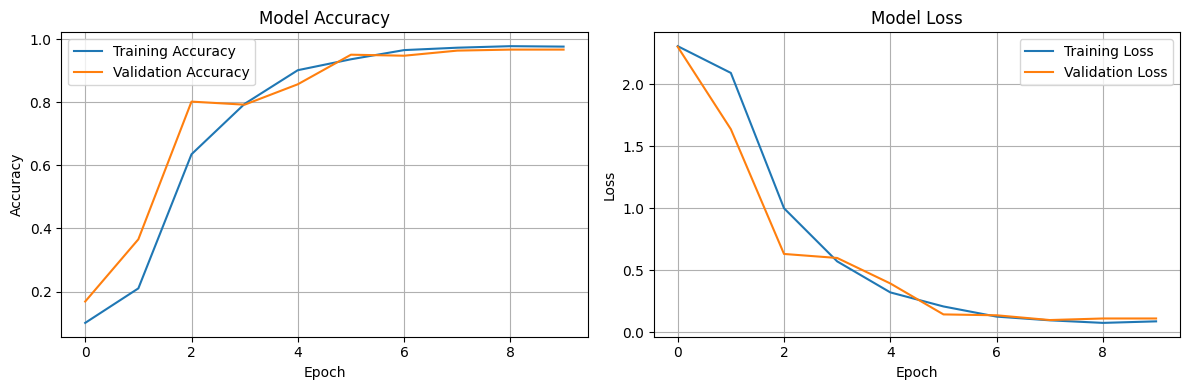

In [19]:
# Plot training history
def plot_training_history(history  ):
	# Plot accuracy
	plt.figure(figsize=(12, 4))
	
	plt.subplot(1, 2, 1)
	plt.plot(history.history['accuracy'], label='Training Accuracy')
	plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
	plt.title('Model Accuracy')
	plt.xlabel('Epoch')
	plt.ylabel('Accuracy')
	plt.legend()
	plt.grid(True)
	
	# Plot loss
	plt.subplot(1, 2, 2)
	plt.plot(history.history['loss'], label='Training Loss')
	plt.plot(history.history['val_loss'], label='Validation Loss')
	plt.title('Model Loss')
	plt.xlabel('Epoch')
	plt.ylabel('Loss')
	plt.legend()
	plt.grid(True)
	
	plt.tight_layout()
	plt.show()

plot_training_history(history)

In [20]:
# Model Evaluation
test_loss, test_accuracy = original_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")    # Fully Connected Layer 3 (Output layer)
#     model.add(layers.Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification
# --- IGNORE ---\


 1/10 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.9062 - loss: 0.3127

2026-01-09 13:41:51.743940: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 186654720 exceeds 10% of free system memory.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9581 - loss: 0.1482
Test Loss: 0.14824968576431274
Test Accuracy: 0.9580644965171814


 1/10 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step

2026-01-09 13:41:52.961916: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 186654720 exceeds 10% of free system memory.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


2026-01-09 13:41:54.239706: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 186654720 exceeds 10% of free system memory.


Test Loss: 0.1482
Test Accuracy: 0.9581


Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        32
           1       0.93      0.93      0.93        27
           2       0.97      1.00      0.99        34
           3       1.00      0.97      0.98        31
           4       1.00      0.95      0.97        19
           5       1.00      1.00      1.00        33
           6       1.00      0.87      0.93        31
           7       0.92      0.94      0.93        35
           8       0.97      0.94      0.96        34
           9       0.89      0.97      0.93        34

    accuracy                           0.96       310
   macro avg       0.96      0.96      0.96       310
weighted avg       0.96      0.96      0.96       310



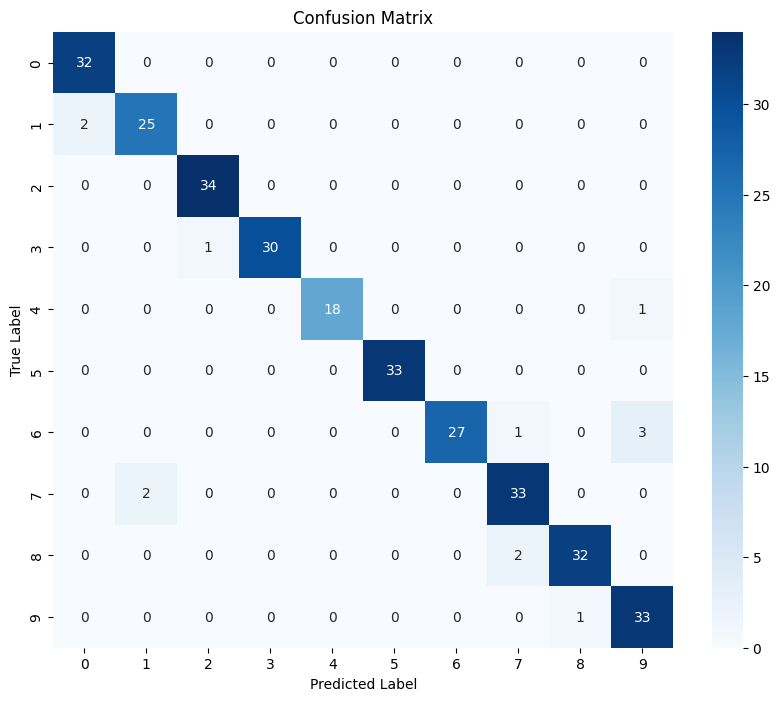


Weighted Precision: 0.9598
Weighted Recall: 0.9581


In [21]:

# Define model evaluation function
def model_Evaluate(original_model, X_test, y_test, label_dic):
	# Make predictions
	y_pred = original_model.predict(X_test)
	y_pred_classes = np.argmax(y_pred, axis=1)
	
	# Calculate metrics
	test_loss, test_accuracy = original_model.evaluate(X_test, y_test, verbose=0)
	
	print(f"Test Loss: {test_loss:.4f}")
	print(f"Test Accuracy: {test_accuracy:.4f}")
	print("\n" + "="*50)
	
	# Classification Report
	print("\nClassification Report:")
	print(classification_report(y_test, y_pred_classes, target_names=list(label_dic.keys())))
	
	# Confusion Matrix
	cm = confusion_matrix(y_test, y_pred_classes)
	plt.figure(figsize=(10, 8))
	sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(label_dic.keys()), yticklabels=list(label_dic.keys()))
	plt.title('Confusion Matrix')
	plt.ylabel('True Label')
	plt.xlabel('Predicted Label')
	plt.show()
	
	# Precision and Recall
	precision = precision_score(y_test, y_pred_classes, average='weighted')
	recall = recall_score(y_test, y_pred_classes, average='weighted')
	
	print(f"\nWeighted Precision: {precision:.4f}")
	print(f"Weighted Recall: {recall:.4f}")

# Evaluate the model
model_Evaluate(original_model, X_test, y_test, label_dic)

In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model


In [23]:
# Save the trained model
original_model.save('ori_alexnet_sign_language_model.h5')

In [24]:
# Load the model if you have saved it already (optional)
model = load_model('ori_alexnet_sign_language_model.h5')

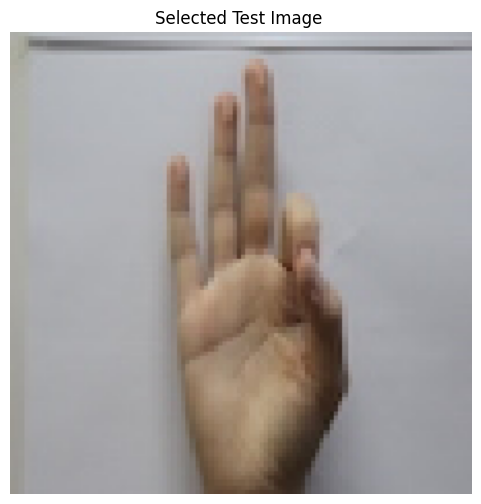

In [26]:
# Path to your test image
img_path = '/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/Course/Project_Sign_Language/src/database/9/IMG_1178.JPG'

# Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))  # Resize image to 224x224
img_array = image.img_to_array(img)  # Convert image to array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Normalize pixel values to [0, 1]


# visualize the selection image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title('Selected Test Image ')
plt.axis('off')
plt.show()


In [27]:
# Make a prediction
predictions = model.predict(img_array)

# If it’s a multi-class classification, you can get the class with the highest probability
predicted_class = np.argmax(predictions, axis=1)

# Print the predicted class
print(f'Predicted class: {predicted_class}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted class: [9]


# My AlexNet Model

In [28]:

# Define the AlexNet architecture
def build_my_alexnet(input_shape, num_classes):
    model = models.Sequential()

    # Conv Layer 1
    model.add(Conv2D(64, (11, 11), strides=4, activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(3, 3), strides=1))
    
    # Conv Layer 2
    model.add(Conv2D(512, (7, 7), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3, 3), strides=2))

    # Conv Layer 3
    model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
    
    # Conv Layer 4
    model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
    
    # Conv Layer 5
    model.add(Conv2D(128, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3, 3), strides=2))
    
    # Flatten the output for the fully connected layers
    model.add(Flatten())
    
    # Fully Connected Layer 1
    model.add(Dense(2048, activation='relu'))
    model.add(Dropout(0.5))  # Dropout to prevent overfitting
    # Fully Connected Layer 2
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(0.5))  # Dropout to prevent overfitting

    # Fully Connected Layer 3 (Output layer)
    model.add(Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification



    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',  # Using sparse categorical cross-entropy for integer labels
        metrics=['accuracy']
    )

    return model

In [ ]:
# # Define input shape and number of classes
# input_shape = (224, 224, 3)  # Images are resized to 224x224x3
# num_classes = len(label_dic)  # Number of classes in the dataset

# # Build the AlexNet model
# my_alex_model = build_my_alexnet(input_shape, num_classes)

In [29]:
# Build the AlexNet model
input_shape = (224, 224, 3)  # Images are resized to 224x224x3
num_classes = len(label_dic)  # Number of classes in the dataset

my_model = build_my_alexnet(input_shape, num_classes)

# Print the model summary
my_model.summary()


/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/Course/Project_Sign_Language/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 64)     │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 52, 52, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 512)    │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 256)    │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 256)    │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 128)    │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2048)           │    37,750,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,223,690 (180.14 MB)

 Trainable params: 47,223,690 (180.14 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:

# Train the model
history1 = my_model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_data=(X_val, y_val))


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.1192 - loss: 2.3079 - val_accuracy: 0.1392 - val_loss: 2.2961
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.3042 - loss: 1.8962 - val_accuracy: 0.6214 - val_loss: 0.8958
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.7089 - loss: 0.8559 - val_accuracy: 0.8803 - val_loss: 0.4006
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.8649 - loss: 0.4316 - val_accuracy: 0.8738 - val_loss: 0.3350
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.8850 - loss: 0.3535 - val_accuracy: 0.9256 - val_loss: 0.2563
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.9307 - loss: 0.2201 - val_accuracy: 0.9288 - val_loss: 0.1850
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9501 - loss: 0.1728 - val_accuracy: 0.9547 - val_loss: 0.1434
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9605 - loss: 0.1427 - val_accuracy: 0.9741 - v

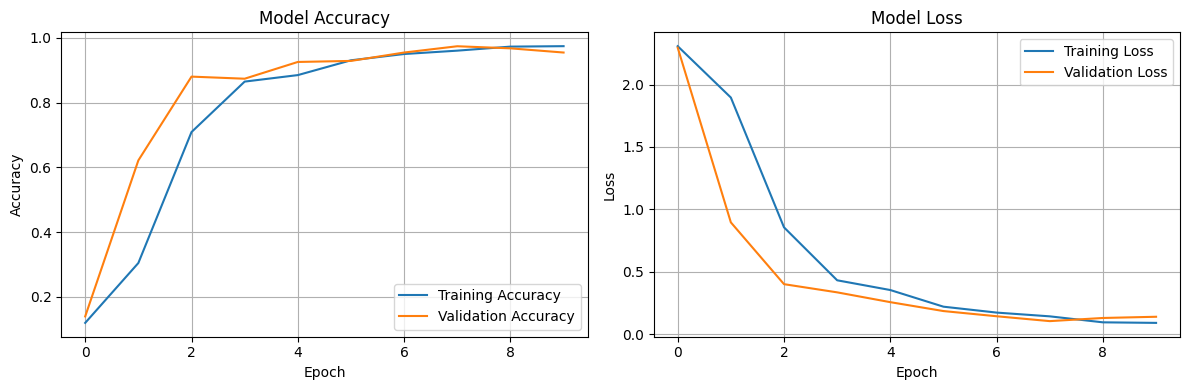

In [31]:
# Plot training history
def plot_training_history(history1):
	# Plot accuracy
	plt.figure(figsize=(12, 4))
	
	plt.subplot(1, 2, 1)
	plt.plot(history1.history['accuracy'], label='Training Accuracy')
	plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
	plt.title('Model Accuracy')
	plt.xlabel('Epoch')
	plt.ylabel('Accuracy')
	plt.legend()
	plt.grid(True)
	
	# Plot loss
	plt.subplot(1, 2, 2)
	plt.plot(history1.history['loss'], label='Training Loss')
	plt.plot(history1.history['val_loss'], label='Validation Loss')
	plt.title('Model Loss')
	plt.xlabel('Epoch')
	plt.ylabel('Loss')
	plt.legend()
	plt.grid(True)
	
	plt.tight_layout()
	plt.show()

plot_training_history(history1)

In [32]:
# Model Evaluation
test_loss, test_accuracy = my_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")    # Fully Connected Layer 3 (Output layer)
#     model.add(layers.Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification
# --- IGNORE ---\


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 668ms/step - accuracy: 0.9355 - loss: 0.2403
Test Loss: 0.24030904471874237
Test Accuracy: 0.9354838728904724


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 664ms/step
Test Loss: 0.2403
Test Accuracy: 0.9355


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        32
           1       1.00      0.89      0.94        27
           2       0.97      1.00      0.99        34
           3       0.94      0.97      0.95        31
           4       0.69      0.95      0.80        19
           5       1.00      0.97      0.98        33
           6       0.96      0.87      0.92        31
           7       0.94      0.83      0.88        35
           8       0.94      0.94      0.94        34
           9       0.94      0.97      0.96        34

    accuracy                           0.94       310
   macro avg       0.93      0.94      0.93       310
weighted avg       0.94      0.94      0.94       310



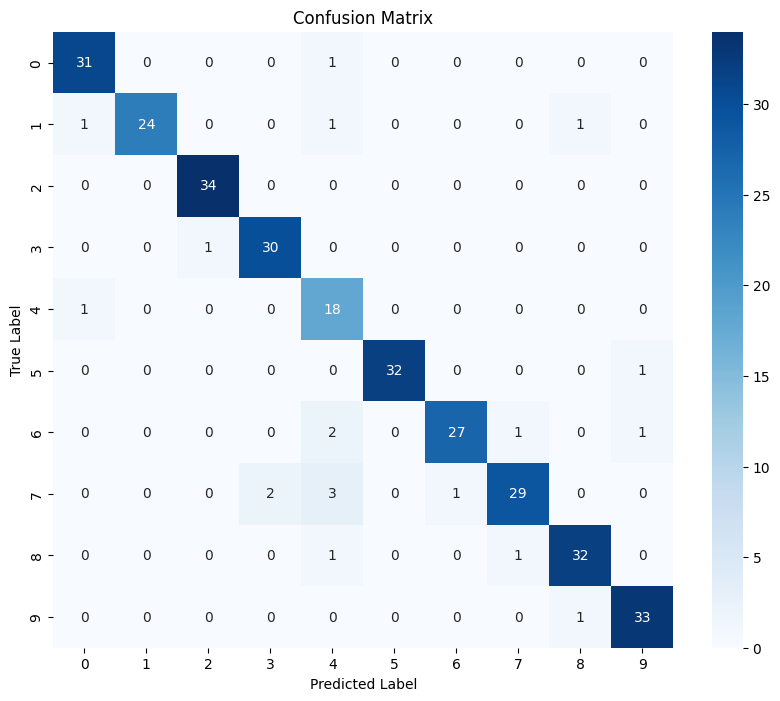


Weighted Precision: 0.9419
Weighted Recall: 0.9355


In [33]:

# Define model evaluation function
def model_Evaluate(my_model, X_test, y_test, label_dic):
	# Make predictions
	y_pred = my_model.predict(X_test)
	y_pred_classes = np.argmax(y_pred, axis=1)
	
	# Calculate metrics
	test_loss, test_accuracy = my_model.evaluate(X_test, y_test, verbose=0)
	
	print(f"Test Loss: {test_loss:.4f}")
	print(f"Test Accuracy: {test_accuracy:.4f}")
	print("\n" + "="*50)
	
	# Classification Report
	print("\nClassification Report:")
	print(classification_report(y_test, y_pred_classes, target_names=list(label_dic.keys())))
	
	# Confusion Matrix
	cm = confusion_matrix(y_test, y_pred_classes)
	plt.figure(figsize=(10, 8))
	sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(label_dic.keys()), yticklabels=list(label_dic.keys()))
	plt.title('Confusion Matrix')
	plt.ylabel('True Label')
	plt.xlabel('Predicted Label')
	plt.show()
	
	# Precision and Recall
	precision = precision_score(y_test, y_pred_classes, average='weighted')
	recall = recall_score(y_test, y_pred_classes, average='weighted')
	
	print(f"\nWeighted Precision: {precision:.4f}")
	print(f"Weighted Recall: {recall:.4f}")

# Evaluate the model
model_Evaluate(my_model, X_test, y_test, label_dic)

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model


In [35]:
# Save the trained model
my_model.save('alexnet_sign_language_model.h5')

In [36]:
# Load the model if you have saved it already (optional)
model = load_model('alexnet_sign_language_model.h5')

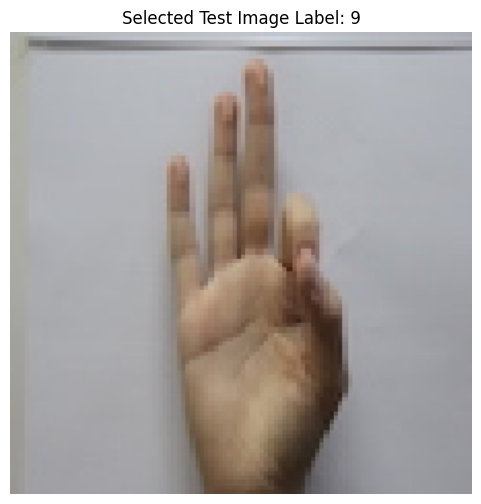

In [37]:
# Path to your test image
img_path = '/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/Course/Project_Sign_Language/src/database/9/IMG_1178.JPG'

# Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))  # Resize image to 224x224
img_array = image.img_to_array(img)  # Convert image to array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Normalize pixel values to [0, 1]

# visualize the selection image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f'Selected Test Image Label: {predicted_class[0]}')
plt.axis('off')
plt.show()


In [38]:
# Make a prediction
predictions = model.predict(img_array)

# If it’s a multi-class classification, you can get the class with the highest probability
predicted_class = np.argmax(predictions, axis=1)

# Print the predicted class
print(f'Predicted class: {predicted_class}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted class: [9]


# II

In [39]:

# Define the AlexNet architecture
from pyexpat import model


def build_my_alexnet1(input_shape, num_classes):
    model1 = models.Sequential()

    # Conv Layer 1
    model1.add(Conv2D(64, (11, 11), strides=4, activation='relu', input_shape=input_shape))
    model1.add(MaxPooling2D(pool_size=(3, 3), strides=2))
    
    # Conv Layer 2
    model1.add(Conv2D(256, (7, 7), padding='same', activation='relu'))
    model1.add(MaxPooling2D(pool_size=(3, 3), strides=2))
    # Conv Layer 3
    model1.add(Conv2D(128, (5, 5), padding='same', activation='relu'))
    
    # Conv Layer 4
    model1.add(Conv2D(64, (5, 5), padding='same', activation='relu'))
    
    # Conv Layer 5
    model1.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
    model1.add(MaxPooling2D(pool_size=(3, 3), strides=2))
    
    # Flatten the output for the fully connected layers
    model1.add(Flatten())
    
    # Fully Connected Layer 1
    model1.add(Dense(512, activation='relu'))
    model1.add(Dropout(0.5))  # Dropout to prevent overfitting
    # Fully Connected Layer 2
    model1.add(Dense(256, activation='relu'))
    model1.add(Dropout(0.5))  # Dropout to prevent overfitting

    # Fully Connected Layer 3 (Output layer)
    model1.add(Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification


    # Compile the model
    model1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',  # Using sparse categorical cross-entropy for integer labels
        metrics=['accuracy']
    )

    return model1

In [40]:
# Build the AlexNet model
input_shape = (224, 224, 3)  # Images are resized to 128x128x3
num_classes = len(label_dic)  # Number of classes in the dataset

my_model1 = build_my_alexnet1(input_shape, num_classes)

# Print the model summary
my_model1.summary()

/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/Course/Project_Sign_Language/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 54, 54, 64)     │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 26, 26, 256)    │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 128)    │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 64)     │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 32)     │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,445,802 (9.33 MB)

 Trainable params: 2,445,802 (9.33 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:

# Train the model
history2 = my_model1.fit(X_train, y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_data=(X_val, y_val))


Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 304ms/step - accuracy: 0.0998 - loss: 2.3056 - val_accuracy: 0.0874 - val_loss: 2.3027
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 291ms/step - accuracy: 0.1137 - loss: 2.3008 - val_accuracy: 0.1424 - val_loss: 2.2952
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 293ms/step - accuracy: 0.1906 - loss: 2.2241 - val_accuracy: 0.3204 - val_loss: 1.8990
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 308ms/step - accuracy: 0.4075 - loss: 1.6976 - val_accuracy: 0.6861 - val_loss: 0.9843
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 294ms/step - accuracy: 0.5918 - loss: 1.1748 - val_accuracy: 0.8026 - val_loss: 0.6437
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 294ms/step - accuracy: 0.7076 - loss: 0.8497 - val_accuracy: 0.8544 - val_loss: 0.4977
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 294ms/step - accuracy: 0.7789 - loss: 0.6550 - val_accuracy: 0.8738 - val_loss: 0.3821
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 296ms/step - accuracy: 0.8399 - loss: 0.4948 - val_accu

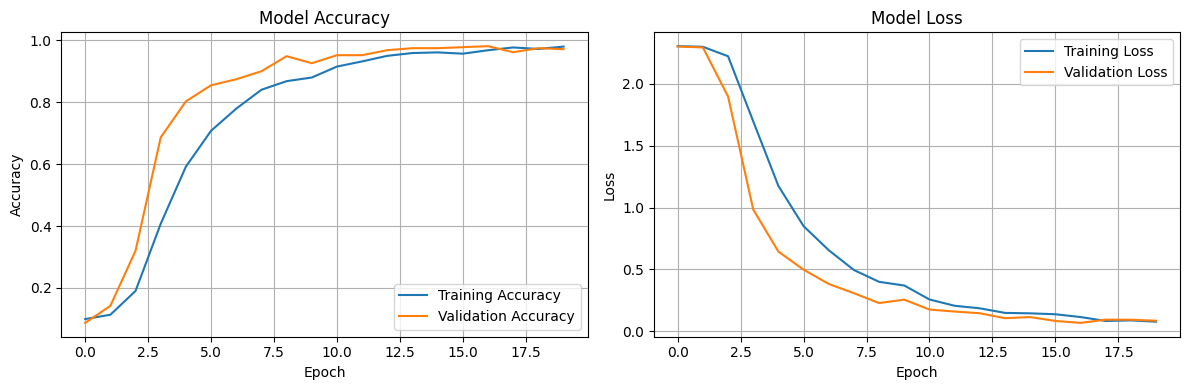

In [42]:
# Plot training history
def plot_training_history(history2):
	# Plot accuracy
	plt.figure(figsize=(12, 4))
	
	plt.subplot(1, 2, 1)
	plt.plot(history2.history['accuracy'], label='Training Accuracy')
	plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
	plt.title('Model Accuracy')
	plt.xlabel('Epoch')
	plt.ylabel('Accuracy')
	plt.legend()
	plt.grid(True)
	
	# Plot loss
	plt.subplot(1, 2, 2)
	plt.plot(history2.history['loss'], label='Training Loss')
	plt.plot(history2.history['val_loss'], label='Validation Loss')
	plt.title('Model Loss')
	plt.xlabel('Epoch')
	plt.ylabel('Loss')
	plt.legend()
	plt.grid(True)
	
	plt.tight_layout()
	plt.show()

plot_training_history(history2)

In [43]:
# Model Evaluation
test_loss, test_accuracy = my_model1.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")    # Fully Connected Layer 3 (Output layer)
#     model.add(layers.Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification
# --- IGNORE ---\


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9710 - loss: 0.0835
Test Loss: 0.08354009687900543
Test Accuracy: 0.9709677696228027


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Test Loss: 0.0835
Test Accuracy: 0.9710


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        32
           1       0.96      1.00      0.98        27
           2       0.97      1.00      0.99        34
           3       1.00      1.00      1.00        31
           4       0.90      1.00      0.95        19
           5       1.00      1.00      1.00        33
           6       0.97      0.90      0.93        31
           7       0.94      0.91      0.93        35
           8       0.97      0.97      0.97        34
           9       1.00      0.97      0.99        34

    accuracy                           0.97       310
   macro avg       0.97      0.97      0.97       310
weighted avg       0.97      0.97      0.97       310



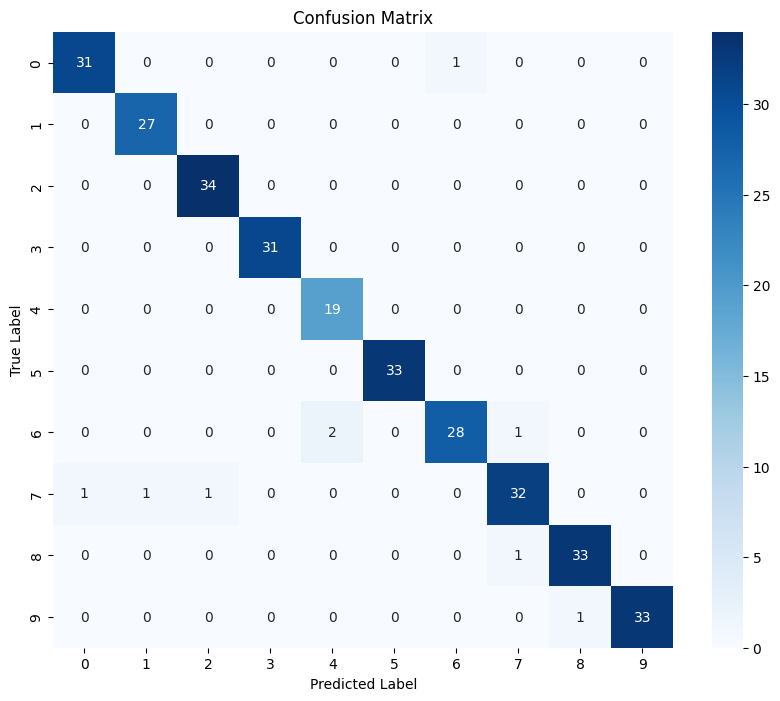


Weighted Precision: 0.9714
Weighted Recall: 0.9710


In [44]:

# Define model evaluation function
def model_Evaluate(my_model1, X_test, y_test, label_dic):
	# Make predictions
	y_pred = my_model1.predict(X_test)
	y_pred_classes = np.argmax(y_pred, axis=1)
	
	# Calculate metrics
	test_loss, test_accuracy = my_model1.evaluate(X_test, y_test, verbose=0)
	
	print(f"Test Loss: {test_loss:.4f}")
	print(f"Test Accuracy: {test_accuracy:.4f}")
	print("\n" + "="*50)
	
	# Classification Report
	print("\nClassification Report:")
	print(classification_report(y_test, y_pred_classes, target_names=list(label_dic.keys())))
	
	# Confusion Matrix
	cm = confusion_matrix(y_test, y_pred_classes)
	plt.figure(figsize=(10, 8))
	sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(label_dic.keys()), yticklabels=list(label_dic.keys()))
	plt.title('Confusion Matrix')
	plt.ylabel('True Label')
	plt.xlabel('Predicted Label')
	plt.show()
	
	# Precision and Recall
	precision = precision_score(y_test, y_pred_classes, average='weighted')
	recall = recall_score(y_test, y_pred_classes, average='weighted')
	
	print(f"\nWeighted Precision: {precision:.4f}")
	print(f"Weighted Recall: {recall:.4f}")

# Evaluate the model
model_Evaluate(my_model1, X_test, y_test, label_dic)

In [45]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model


In [46]:
# Save the trained model
my_model1.save('alexnet_sign_language_model1.h5')

In [47]:
# Load the model if you have saved it already (optional)
model = load_model('alexnet_sign_language_model1.h5')


True label: 1


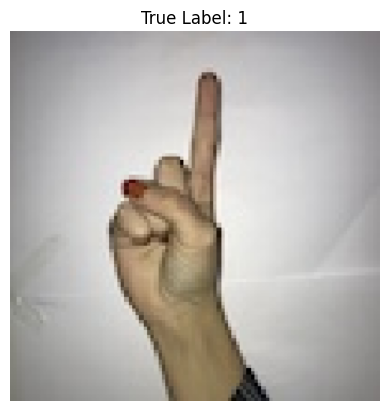

In [58]:
# Select a random image from the test set
random_idx = np.random.randint(0, len(X_test))
img_array = X_test[random_idx:random_idx+1]  # Keep batch dimension

# Get the true label for this image
true_label = y_test[random_idx]
true_label_name = list(label_dic.keys())[list(label_dic.values()).index(true_label)]

# print(f"Random test image index: {random_idx}")
print(f"True label: {true_label_name}")

# Visualize the selected image
plt.imshow(img_array[0])
plt.title(f"True Label: {true_label_name}")
plt.axis('off')
plt.show()

In [59]:
# Make a prediction
predictions = model.predict(img_array)

# If it’s a multi-class classification, you can get the class with the highest probability
predicted_class = np.argmax(predictions, axis=1)

# Print the predicted class
print(f'Predicted class: {predicted_class}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicted class: [1]
